In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

print("Data loaded")
print(f"Train : {X_train.shape} | Bug rate: {y_train.mean():.1%}")
print(f"Test  : {X_test.shape}  | Bug rate: {y_test.mean():.1%}")

Data loaded
Train : (720, 26) | Bug rate: 70.4%
Test  : (180, 26)  | Bug rate: 91.7%


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)
import joblib

print("All libraries imported")

All libraries imported


In [4]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42),
    
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=10,
        random_state=42, n_jobs=-1),
    
    'XGBoost': XGBClassifier(
        n_estimators=200, learning_rate=0.1,
        max_depth=6, use_label_encoder=False,
        eval_metric='logloss', random_state=42),
    
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.1,
        max_depth=5, random_state=42),
    
    'SVM': SVC(
        kernel='rbf', probability=True, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"Training {name}...", end=' ')
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    
    results[name] = {
        'model'    : model,
        'accuracy' : accuracy_score(y_test, y_pred),
        'f1'       : f1_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall'   : recall_score(y_test, y_pred),
        'roc_auc'  : roc_auc_score(y_test, y_prob),
        'y_pred'   : y_pred,
        'y_prob'   : y_prob
    }
    print(f"F1={results[name]['f1']:.3f} | AUC={results[name]['roc_auc']:.3f}")

Training Logistic Regression... F1=0.932 | AUC=0.874
Training Random Forest... F1=0.933 | AUC=0.864
Training XGBoost... F1=0.930 | AUC=0.901
Training Gradient Boosting... F1=0.933 | AUC=0.895
Training SVM... F1=0.945 | AUC=0.850


In [5]:
print("MODEL COMPARISON\n")

metrics_df = pd.DataFrame({
    name: {
        'Accuracy' : v['accuracy'],
        'F1 Score' : v['f1'],
        'Precision': v['precision'],
        'Recall'   : v['recall'],
        'ROC-AUC'  : v['roc_auc']
    }
    for name, v in results.items()
}).T.round(4)

print(metrics_df.to_string())

best_model_name = metrics_df['F1 Score'].idxmax()
print(f"\n Best model by F1: {best_model_name}")
print(f"   F1 Score : {metrics_df.loc[best_model_name,'F1 Score']:.4f}")
print(f"   Accuracy : {metrics_df.loc[best_model_name,'Accuracy']:.4f}")
print(f"   ROC-AUC  : {metrics_df.loc[best_model_name,'ROC-AUC']:.4f}")

MODEL COMPARISON

                     Accuracy  F1 Score  Precision  Recall  ROC-AUC
Logistic Regression    0.8778    0.9321     0.9497  0.9152   0.8739
Random Forest          0.8778    0.9325     0.9441  0.9212   0.8642
XGBoost                0.8722    0.9297     0.9383  0.9212   0.9006
Gradient Boosting      0.8778    0.9325     0.9441  0.9212   0.8954
SVM                    0.9000    0.9451     0.9509  0.9394   0.8497

 Best model by F1: SVM
   F1 Score : 0.9451
   Accuracy : 0.9000
   ROC-AUC  : 0.8497


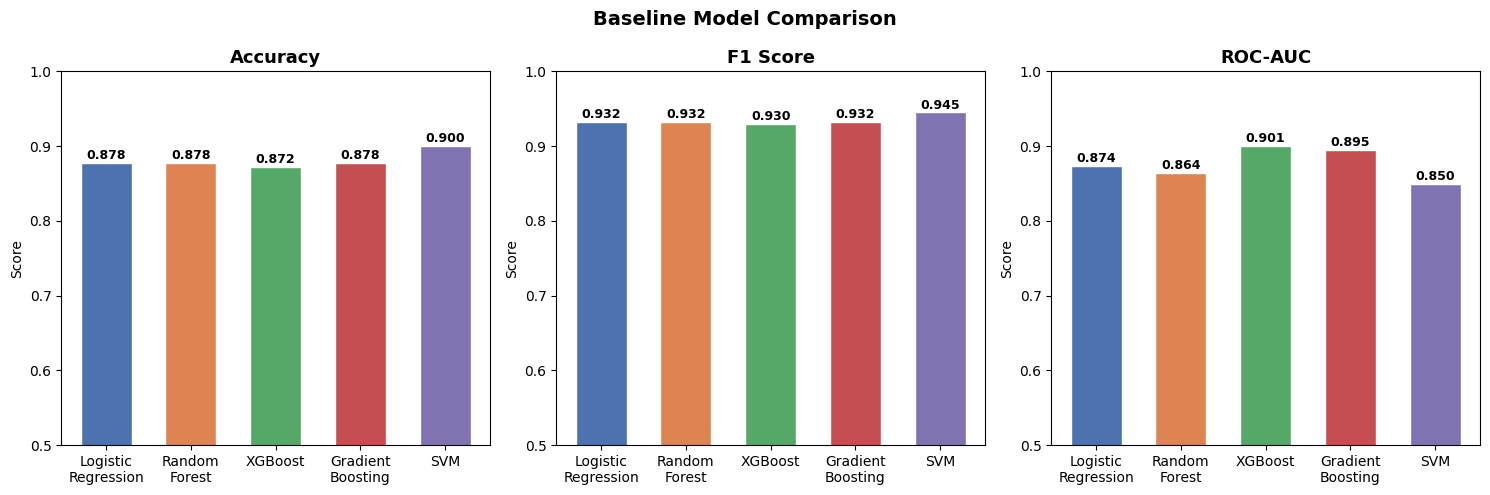

Saved → data/model_comparison.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2']
model_names = [n.replace(' ','\n') for n in metrics_df.index]

for i, metric in enumerate(['Accuracy','F1 Score','ROC-AUC']):
    axes[i].bar(model_names, metrics_df[metric], 
                color=colors, edgecolor='white', width=0.6)
    axes[i].set_title(metric, fontsize=13, fontweight='bold')
    axes[i].set_ylim(0.5, 1.0)
    axes[i].set_ylabel('Score')
    for j, v in enumerate(metrics_df[metric]):
        axes[i].text(j, v + 0.005, f'{v:.3f}', 
                     ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Baseline Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → data/model_comparison.png")

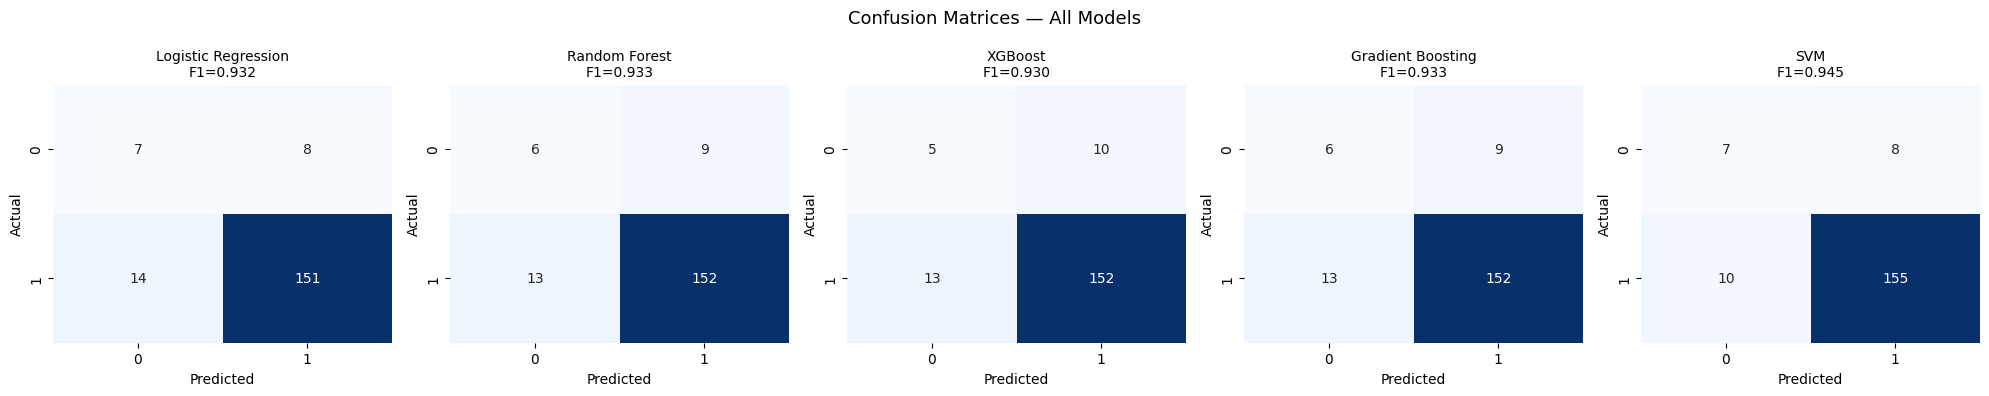

 Saved- data/confusion_matrices.png


In [7]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                ax=axes[i], cbar=False)
    axes[i].set_title(f'{name}\nF1={res["f1"]:.3f}', fontsize=10)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=13)
plt.tight_layout()
plt.savefig('../data/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved- data/confusion_matrices.png")

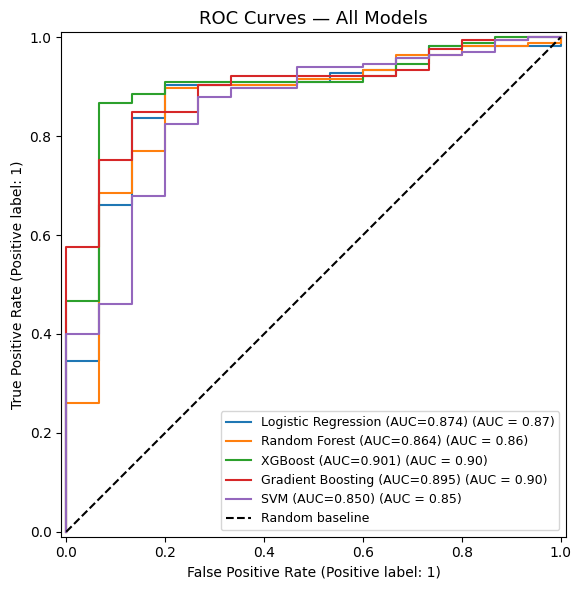

 Saved- data/roc_curves.png


In [8]:
plt.figure(figsize=(8, 6))

for name, res in results.items():
    RocCurveDisplay.from_predictions(
        y_test, res['y_prob'],
        name=f"{name} (AUC={res['roc_auc']:.3f})",
        ax=plt.gca()
    )

plt.plot([0,1],[0,1],'k--', label='Random baseline')
plt.title('ROC Curves — All Models', fontsize=13)
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('../data/roc_curves.png', dpi=150)
plt.show()
print(" Saved- data/roc_curves.png")

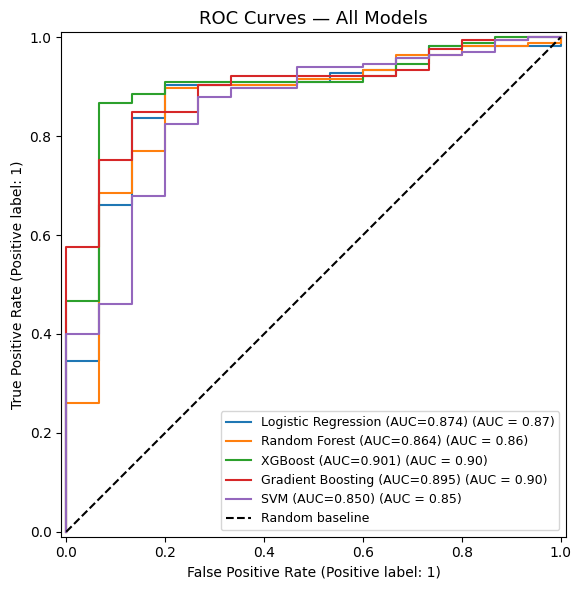

 Saved → data/roc_curves.png


In [9]:
plt.figure(figsize=(8, 6))

for name, res in results.items():
    RocCurveDisplay.from_predictions(
        y_test, res['y_prob'],
        name=f"{name} (AUC={res['roc_auc']:.3f})",
        ax=plt.gca()
    )

plt.plot([0,1],[0,1],'k--', label='Random baseline')
plt.title('ROC Curves — All Models', fontsize=13)
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('../data/roc_curves.png', dpi=150)
plt.show()
print(" Saved → data/roc_curves.png")


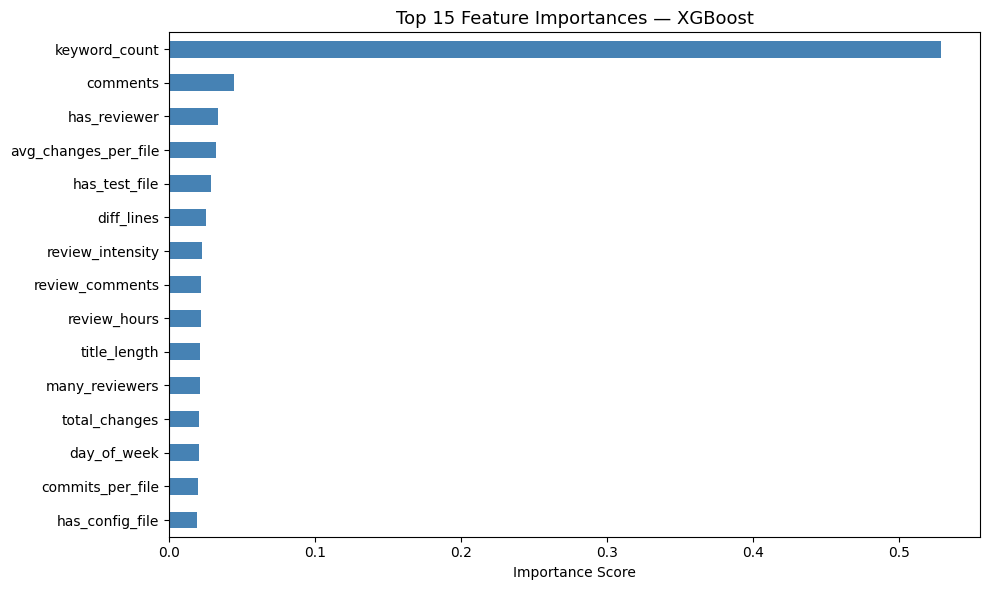

Top 10 most important features:
keyword_count           0.528881
comments                0.044186
has_reviewer            0.033536
avg_changes_per_file    0.032287
has_test_file           0.028831
diff_lines              0.025579
review_intensity        0.022614
review_comments         0.021654
review_hours            0.021634
title_length            0.021012

 1 feature: keyword_count


In [10]:
best_xgb = results['XGBoost']['model']
feature_names = X_train.columns.tolist()

feat_imp = pd.Series(
    best_xgb.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(15).plot(kind='barh', color='steelblue')
plt.title('Top 15 Feature Importances — XGBoost', fontsize=13)
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../data/feature_importance.png', dpi=150)
plt.show()

print("Top 10 most important features:")
print(feat_imp.head(10).to_string())
print(f"\n 1 feature: {feat_imp.idxmax()}")

In [11]:
print("SAVING MODELS ")

# Save all models
for name, res in results.items():
    filename = name.lower().replace(' ','_')
    joblib.dump(res['model'], f'../data/processed/{filename}_model.pkl')
    print(f"Saved {filename}_model.pkl")

# Save classification report for best model
best = best_model_name
report = classification_report(
    y_test, results[best]['y_pred'],
    target_names=['Clean PR', 'Bug Fix PR']
)
print(f"\nClassification Report — {best}:")
print(report)

with open('../data/processed/best_model_report.txt', 'w') as f:
    f.write(f"Best Model: {best}\n\n")
    f.write(report)
print(" Report saved")

SAVING MODELS 
Saved logistic_regression_model.pkl
Saved random_forest_model.pkl
Saved xgboost_model.pkl
Saved gradient_boosting_model.pkl
Saved svm_model.pkl

Classification Report — SVM:
              precision    recall  f1-score   support

    Clean PR       0.41      0.47      0.44        15
  Bug Fix PR       0.95      0.94      0.95       165

    accuracy                           0.90       180
   macro avg       0.68      0.70      0.69       180
weighted avg       0.91      0.90      0.90       180

 Report saved


In [12]:

print(f"Models trained    : {len(models)}")
print(f"Best model       : {best_model_name}")
print(f"   Accuracy         : {results[best_model_name]['accuracy']:.1%}")
print(f"   F1 Score         : {results[best_model_name]['f1']:.3f}")
print(f"   ROC-AUC          : {results[best_model_name]['roc_auc']:.3f}")
print(f"Top feature      : {feat_imp.idxmax()}")

Models trained    : 5
Best model       : SVM
   Accuracy         : 90.0%
   F1 Score         : 0.945
   ROC-AUC          : 0.850
Top feature      : keyword_count
